# Experiments results for transfer learning

Here you will find plots and statistics related to experiments conducted for my thesis. The 2 deep learning model architectures examined are transformer and LSTM. The models were trained with these parameters:
- Transformer: 30 epochs with early stopping
- LSTM: 5 epochs with early stopping

## Loading the required python packages for processing

Loading global constant variables as well as useful functions

In [2]:
import pandas as pd

DATASET_NAMES = ("iotid20", "usfc-tfc-2016", "IoT-DS2", "CIC-USNW-NB15", "mqtt-iot-ids2020", "ids-2018", "IoT-23")
DATASET_MAP = dict(zip(range(1, len(DATASET_NAMES) + 1), DATASET_NAMES))

def get_models_performance(transformer_csv, lstm_csv):
    transformer_df = pd.read_csv(transformer_csv)
    lstm_df = pd.read_csv(lstm_csv)
    normal_accuracy_per_dataset = pd.DataFrame()
    attack_accuracy_per_dataset = pd.DataFrame()
    for i, dataset_name in DATASET_MAP.items():
        trans_normals_accuracy = transformer_df.loc[(transformer_df["Class"] == 'Normal') & (transformer_df["Fold #"] == i)]["Accuracy"].mean()
        trans_attack_accuracy = transformer_df.loc[(transformer_df["Class"] == 'Attack') & (transformer_df["Fold #"] == i)]["Accuracy"].mean()
        lstm_normals_accuracy = lstm_df.loc[(lstm_df["Class"] == 'Normal') & (lstm_df["Fold #"] == i)]["Accuracy"].mean()
        lstm_attack_accuracy = lstm_df.loc[(lstm_df["Class"] == 'Attack') & (lstm_df["Fold #"] == i)]["Accuracy"].mean()
        normal_accuracy_per_dataset[dataset_name] = [trans_normals_accuracy, lstm_normals_accuracy]
        normal_accuracy_per_dataset["Model"] = ["Transformer", "LSTM"]
        attack_accuracy_per_dataset[dataset_name] = [trans_attack_accuracy, lstm_attack_accuracy]
        attack_accuracy_per_dataset["Model"] = ["Transformer", "LSTM"]

    attack_accuracy_per_dataset = attack_accuracy_per_dataset.set_index("Model")
    normal_accuracy_per_dataset = normal_accuracy_per_dataset.set_index("Model")
    return attack_accuracy_per_dataset, normal_accuracy_per_dataset

def get_binary_models_performance(transformer_csv, lstm_csv):
    transformer_df = pd.read_csv(transformer_csv)
    lstm_df = pd.read_csv(lstm_csv)
    accuracy_per_dataset = pd.DataFrame()
    for i, dataset_name in DATASET_MAP.items():
        trans_accuracy = transformer_df.loc[transformer_df["Fold #"] == i]["Accuracy"].mean()
        lstm_accuracy = lstm_df.loc[lstm_df["Fold #"] == i]["Accuracy"].mean()
        accuracy_per_dataset[dataset_name] = [trans_accuracy, lstm_accuracy]
        accuracy_per_dataset["Model"] = ["Transformer", "LSTM"]
    accuracy_per_dataset = accuracy_per_dataset.set_index("Model")
    return accuracy_per_dataset

## Transfer learning results

The experiments for transfer learning are;
1. Zero shot. One dataset is used for testing, the rest are used for training.
2. Few shot. Unlike zero shot, on training set a few samples are used from testing dataset. For our case, 1000 samples per class

Both experiments were run with the following configurations;
1. All features of datasets. Network specifif features included
2. Network specific features removed

### Zero shot tranfer learning

#### All network features included
Metrics per class:

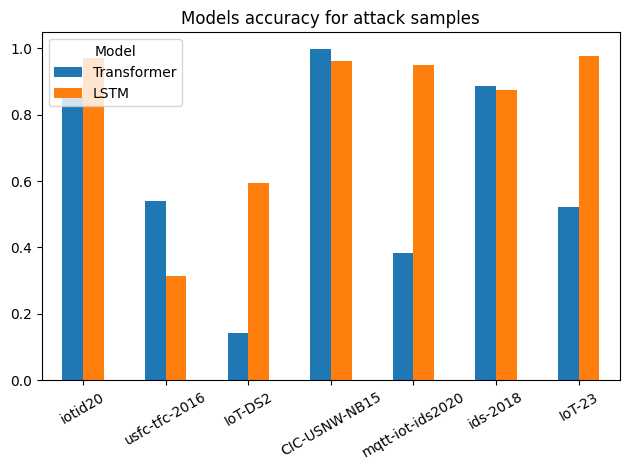

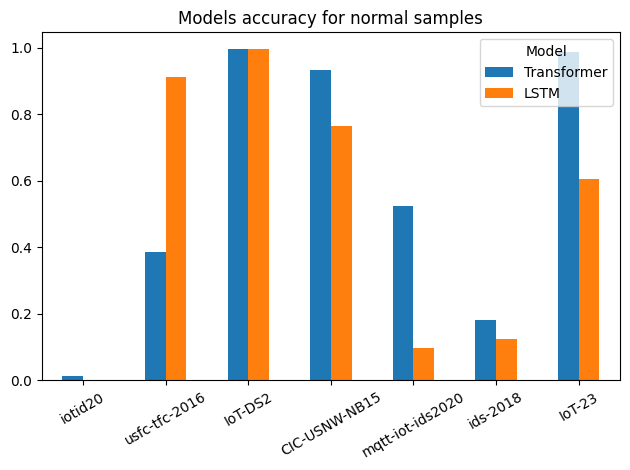

In [18]:
transformer_csv = "../tests/results/reports/transformer/zero_shot/with_network_specific_features/30_epochs_early_stop/results_transformer_TL_zero_shot.csv"
lstm_csv = "../tests/results/reports/lstm/zero_shot/with_network_specific_features/5_epochs_early_stop/results_lstm_TL_zero_shot.csv"
attack_accuracy_per_dataset, normal_accuracy_per_dataset = get_models_performance(transformer_csv, lstm_csv)

ax = attack_accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy for attack samples")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("attack-accuracy.pdf")

ax = normal_accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy for normal samples")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("normal-accuracy.pdf")


Binary metrics:

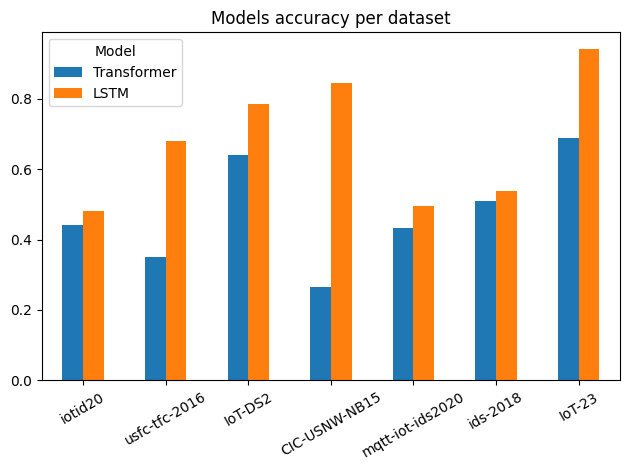

In [19]:
transformer_csv = "../tests/results/reports/transformer/zero_shot/with_network_specific_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_zero_shot.csv"
lstm_csv = "../tests/results/reports/lstm/zero_shot/with_network_specific_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_zero_shot.csv"
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv)

ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_zero_shot.pdf")


#### Network specific features removed

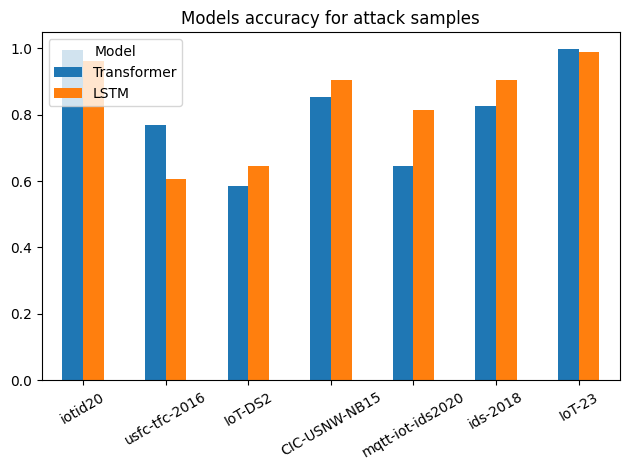

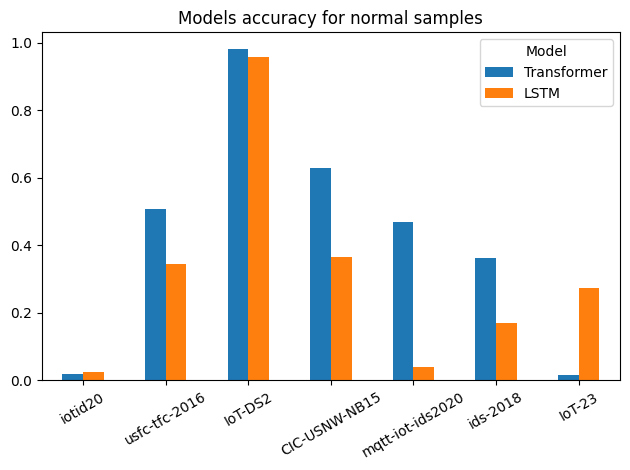

In [20]:
transformer_csv = "../tests/results/reports/transformer/zero_shot/without_network_specific_features_improved/30_epochs_early_stop/results_transformer_TL_removed_zero_shot.csv"
lstm_csv = "../tests/results/reports/lstm/zero_shot/without_network_specific_features_improved/5_epochs_early_stop/results_lstm_TL_removed_zero_shot.csv"
attack_accuracy_per_dataset, normal_accuracy_per_dataset = get_models_performance(transformer_csv, lstm_csv)

ax = attack_accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy for attack samples")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("attack-accuracy.pdf")

ax = normal_accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy for normal samples")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("normal-accuracy.pdf")

Binary metrics:

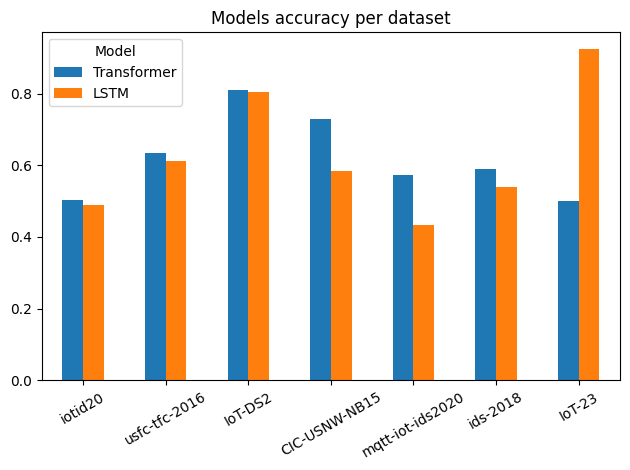

In [21]:
transformer_csv = "../tests/results/reports/transformer/zero_shot/without_network_specific_features_improved/30_epochs_early_stop/binary_metrics/results_transformer_TL_removed_zero_shot.csv"
lstm_csv = "../tests/results/reports/lstm/zero_shot/without_network_specific_features_improved/5_epochs_early_stop/binary_metrics/results_lstm_TL_removed_zero_shot.csv"
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv)

ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_removed_zero_shot.pdf")

### Few shot transfer learning
The following results are for 1000 samples per class infused from test set into the training set.
#### All network features included


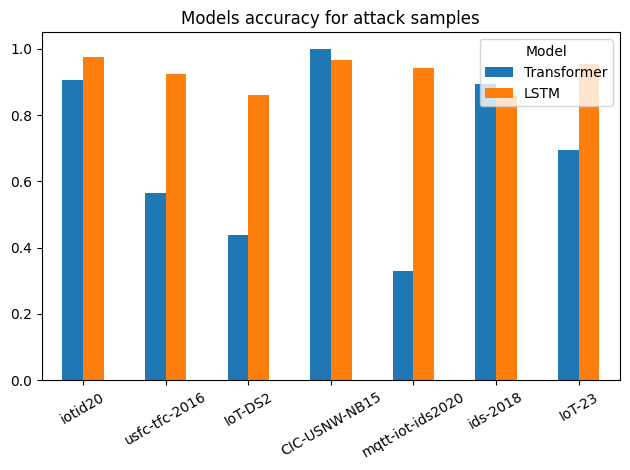

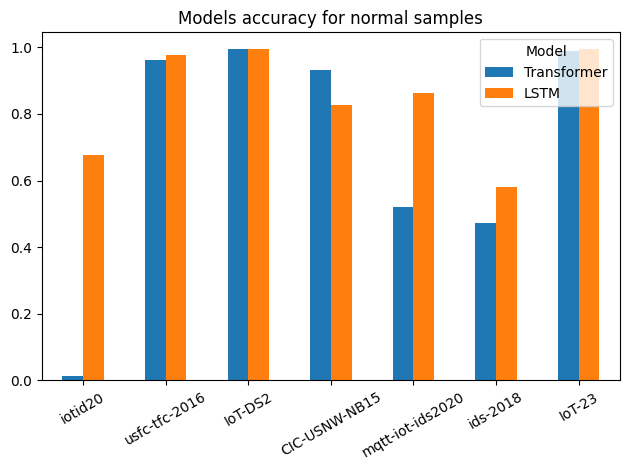

In [22]:
transformer_csv = "../tests/results/reports/transformer/few_shot/1000_samples/with_network_specific_features/30_epochs_early_stop/results_transformer_TL_few_shot.csv"
lstm_csv = "../tests/results/reports/lstm/few_shot/1000_samples/with_network_specific_features/5_epochs_early_stop/results_lstm_TL_few_shot.csv"
attack_accuracy_per_dataset, normal_accuracy_per_dataset = get_models_performance(transformer_csv, lstm_csv)

ax = attack_accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy for attack samples")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("attack-accuracy.pdf")

ax = normal_accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy for normal samples")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("normal-accuracy.pdf")

Binary metrics:

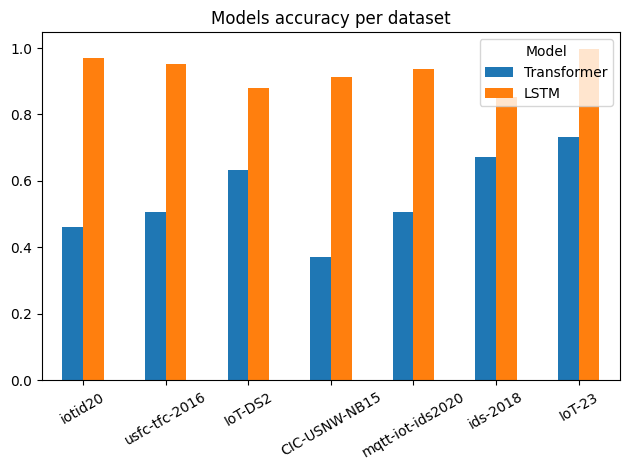

In [23]:
transformer_csv = "../tests/results/reports/transformer/few_shot/1000_samples/with_network_specific_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_few_shot.csv"
lstm_csv = "../tests/results/reports/lstm/few_shot/1000_samples/with_network_specific_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_few_shot.csv"
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv)

ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_few_shot_1000.pdf")

#### Without network-specific features

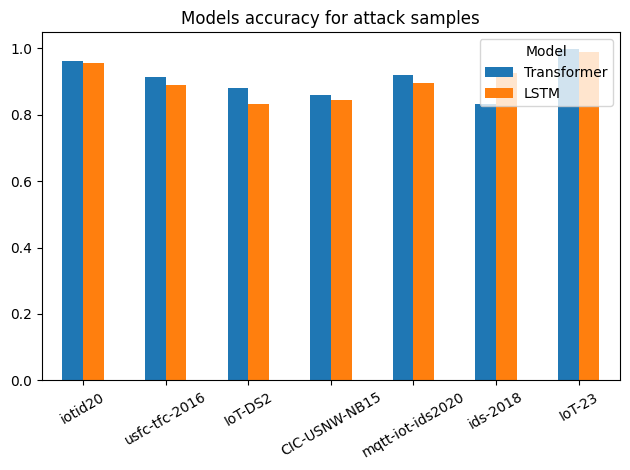

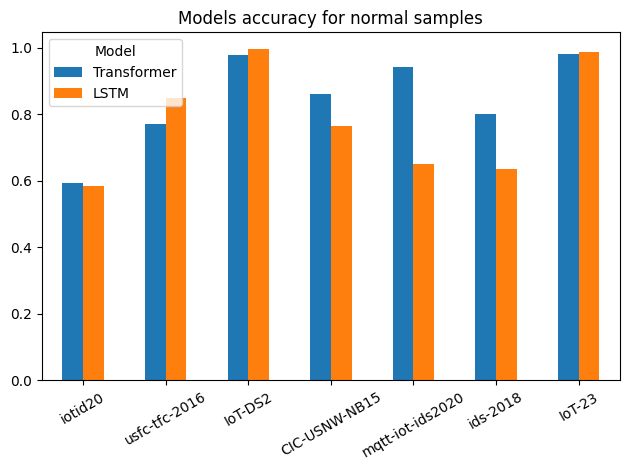

In [24]:
transformer_csv = "../tests/results/reports/transformer/few_shot/1000_samples/without_network_specific_features_improved/30_epochs_early_stop/results_transformer_TL_removed_few_shot.csv"
lstm_csv = "../tests/results/reports/lstm/few_shot/1000_samples/without_network_specific_features_improved/5_epochs_early_stop/results_lstm_TL_removed_few_shot.csv"
attack_accuracy_per_dataset, normal_accuracy_per_dataset = get_models_performance(transformer_csv, lstm_csv)

ax = attack_accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy for attack samples")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("attack-accuracy.pdf")

ax = normal_accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy for normal samples")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("normal-accuracy.pdf")

Binary metrics:

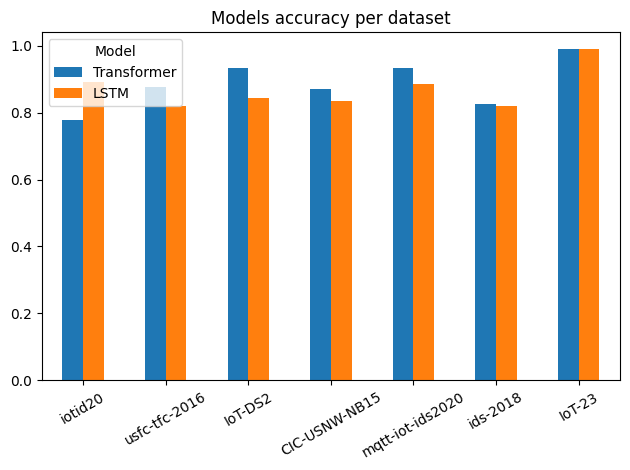

In [25]:
transformer_csv = "../tests/results/reports/transformer/few_shot/1000_samples/without_network_specific_features_improved/30_epochs_early_stop/binary_metrics/results_transformer_TL_removed_few_shot.csv"
lstm_csv = "../tests/results/reports/lstm/few_shot/1000_samples/without_network_specific_features_improved/5_epochs_early_stop/binary_metrics/results_lstm_TL_removed_few_shot.csv"
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv)

ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_removed_few_shot_1000.pdf")

The following results are for 100 samples per class infused from test set into the training set.
#### With network specific features:

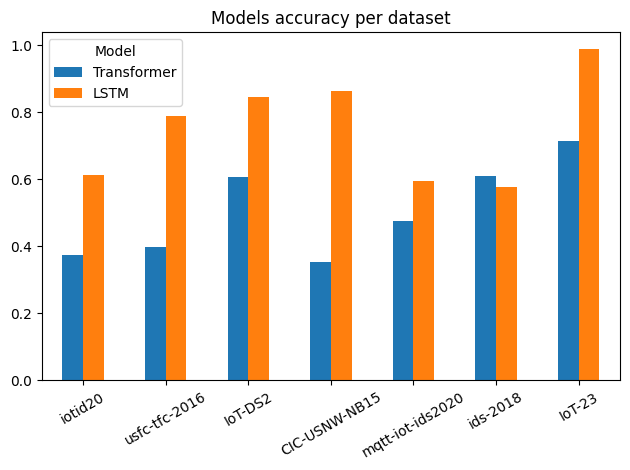

In [26]:
transformer_csv = "../tests/results/reports/transformer/few_shot/100_samples/with_network_specific_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_few_shot.csv"
lstm_csv = "../tests/results/reports/lstm/few_shot/100_samples/with_network_specific_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_few_shot.csv"
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv)

ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_few_shot_100.pdf")

#### Without network specific features:


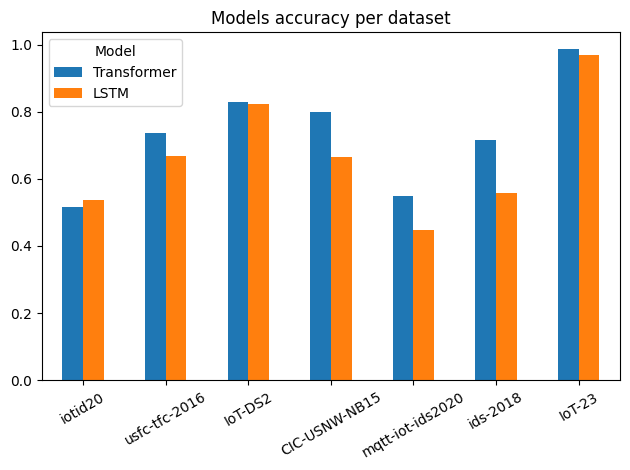

In [27]:
transformer_csv = "../tests/results/reports/transformer/few_shot/100_samples/without_network_specific_features_improved/30_epochs_early_stop/binary_metrics/results_transformer_TL_removed_few_shot.csv"
lstm_csv = "../tests/results/reports/lstm/few_shot/100_samples/without_network_specific_features_improved/5_epochs_early_stop/binary_metrics/results_lstm_TL_removed_few_shot.csv"
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv)

ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_removed_few_shot_100.pdf")

The following results are for 10 samples per class infused from test set into training set
#### With network specific features

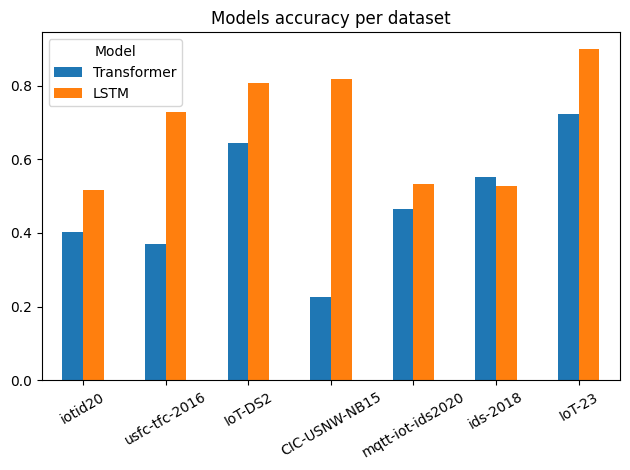

In [3]:
transformer_csv = "../tests/results/reports/transformer/few_shot/10_samples/with_network_specific_features/30_epochs_early_stop/binary_metrics/results_transformer_TL_few_shot.csv"
lstm_csv = "../tests/results/reports/lstm/few_shot/10_samples/with_network_specific_features/5_epochs_early_stop/binary_metrics/results_lstm_TL_few_shot.csv"
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv)

ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_few_shot_10.pdf")

#### Without network specific features

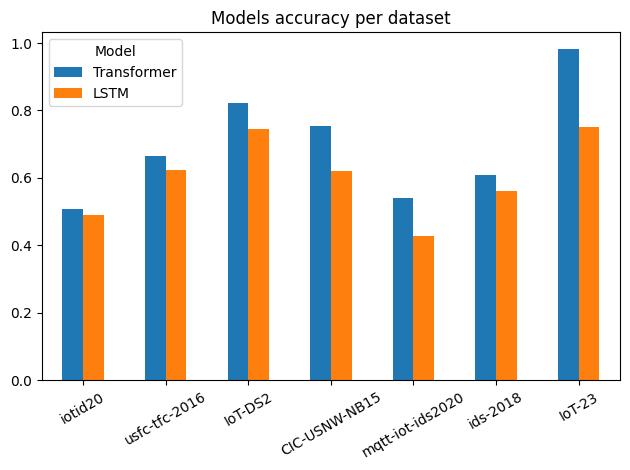

In [5]:
transformer_csv = "../tests/results/reports/transformer/few_shot/10_samples/without_network_specific_features_improved/30_epochs_early_stop/binary_metrics/results_transformer_TL_removed_few_shot.csv"
lstm_csv = "../tests/results/reports/lstm/few_shot/10_samples/without_network_specific_features_improved/5_epochs_early_stop/binary_metrics/results_lstm_TL_removed_few_shot.csv"
accuracy_per_dataset = get_binary_models_performance(transformer_csv, lstm_csv)

ax = accuracy_per_dataset.T.plot(kind='bar', rot=30)
ax.set_title("Models accuracy per dataset")
fig = ax.get_figure()
fig.tight_layout(h_pad=3)
fig.savefig("model_accuracy_removed_few_shot_10.pdf")